In [19]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Using Pandas library to read the csv file.This stores CSV file in ram.Dynamically stored.
touchpoints=pd.read_csv("/workspaces/Multi-Touch-Marketing-Attribution-ROI-Dashboard/Raw_Data/user_touchpoints.csv.xls")

In [15]:
print(touchpoints)

      user_id  timestamp         region   device         channel  \
0      U00001 2025-05-14  North America  Desktop  Organic Search   
1      U00001 2025-05-16  North America  Desktop      TikTok Ads   
2      U00002 2025-04-04  North America  Desktop      TikTok Ads   
3      U00002 2025-04-09  North America  Desktop    Facebook Ads   
4      U00003 2025-01-23   Asia Pacific   Tablet  Organic Search   
...       ...        ...            ...      ...             ...   
45810  U02465 2025-02-04  North America  Desktop      TikTok Ads   
45811  U04713 2025-04-13  North America   Tablet    Facebook Ads   
45812  U05414 2025-05-30         Europe   Mobile  Organic Search   
45813  U00655 2025-05-06         Europe  Desktop  Organic Search   
45814  U00530 2025-01-27  North America   Mobile      TikTok Ads   

              campaign    event_type      utm_source utm_medium  \
0      Organic Landing         Visit  organic_search        NaN   
1      Influencer Push  Product View      tiktok_

In [4]:
#head() function is used to see first few rows of csv file.
touchpoints.head()

,user_id,timestamp,region,device,channel,campaign,event_type,utm_source,utm_medium,utm_campaign
0,U00001,2025-05-14 18:56:35,North America,Desktop,Organic Search,Organic Landing,Visit,organic_search,NaN,Organic Landing
1,U00001,05/16/2025 12:56,North America,Desktop,TikTok Ads,Influencer Push,Product View,tiktok_ads,social,Influencer Push
2,U00002,04/04/2025 15:58,North America,Desktop,TikTok Ads,UGC Campaign,Product View,tiktok_ads,organic,UGC Campaign
3,U00002,2025-04-09 10:58:50,North America,Desktop,Facebook Ads,Retargeting,Visit,facebook_ads,organic,Retargeting
4,U00003,2025-01-23 07:05:32,Asia Pacific,Tablet,Organic Search,Organic Landing,Product View,organic_search,organic,Organic Landing


In [5]:
touchpoints.sample(5)

,user_id,timestamp,region,device,channel,campaign,event_type,utm_source,utm_medium,utm_campaign
43568,U09696,2025-02-25 10:52:10,Europe,Mobile,TikTok Ads,Influencer Push,Visit,tiktok_ads,cpc,Influencer Push
14367,U03198,2025-07-12 23:06:10,Asia Pacific,Tablet,Google Ads,Brand Search,Signup,google_ads,organic,Brand Search
25822,U05754,2025-04-08 20:09:02,South America,Desktop,Organic Search,Organic Landing,Visit,organic_search,cpc,Organic Landing
29209,U06497,2025-02-05 04:44:42,South America,Mobile,Google Ads,Brand Search,Signup,google_ads,cpc,Brand Search
32114,U07141,2025-05-28 22:41:07,Europe,Tablet,Facebook Ads,Winter Sale,Product View,facebook_ads,cpc,Winter Sale


In [6]:
#Using info() function helps understand data
#Can verify Columns, total columns, Non-Null Columns, Datatypes
touchpoints.info()

<class 'pandas.DataFrame'>
RangeIndex: 45815 entries, 0 to 45814
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       45815 non-null  str  
 1   timestamp     45815 non-null  str  
 2   region        45815 non-null  str  
 3   device        45815 non-null  str  
 4   channel       45815 non-null  str  
 5   campaign      45815 non-null  str  
 6   event_type    45815 non-null  str  
 7   utm_source    43491 non-null  str  
 8   utm_medium    43542 non-null  str  
 9   utm_campaign  45815 non-null  str  
dtypes: str(10)
memory usage: 3.5 MB


In [7]:
#Describe() functions gives a statistical Summary of the dataframe.

touchpoints.describe()

,user_id,timestamp,region,device,channel,campaign,event_type,utm_source,utm_medium,utm_campaign
count,45815,45815,45815,45815,45815,45815,45815,43491,43542,45815
unique,10000,44256,4,3,4,11,3,4,3,11
top,U07596,03/06/2025 02:48,North America,Desktop,Organic Search,Organic Landing,Visit,organic_search,organic,Organic Landing
freq,10,4,11944,15378,11482,5759,15386,10926,14577,5759


In [8]:
#Converting timestamp column from str datatype to datetime dataype. 
touchpoints["timestamp"] = pd.to_datetime(
    touchpoints["timestamp"],
    format="mixed"
)

#Normalizing datetime format.Converts time in datetime to zeros.
#Handles data efficiently while working with Power BI.
touchpoints['timestamp'] = touchpoints['timestamp'].dt.normalize()

In [9]:
#Using info() function helps understand data
#Can verify Columns, total columns, Non-Null Columns, Datatypes
#Using this particular line to check if the datatype is changed from str to datetime
touchpoints.info()

<class 'pandas.DataFrame'>
RangeIndex: 45815 entries, 0 to 45814
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       45815 non-null  str           
 1   timestamp     45815 non-null  datetime64[us]
 2   region        45815 non-null  str           
 3   device        45815 non-null  str           
 4   channel       45815 non-null  str           
 5   campaign      45815 non-null  str           
 6   event_type    45815 non-null  str           
 7   utm_source    43491 non-null  str           
 8   utm_medium    43542 non-null  str           
 9   utm_campaign  45815 non-null  str           
dtypes: datetime64[us](1), str(9)
memory usage: 3.5 MB


In [10]:
#Checking Duplicates.
print("Duplicate rows:", touchpoints.duplicated().sum())

Duplicate rows: 916


In [11]:
#Checking missing values.
print(touchpoints.isnull().sum())

user_id            0
timestamp          0
region             0
device             0
channel            0
campaign           0
event_type         0
utm_source      2324
utm_medium      2273
utm_campaign       0
dtype: int64


In [13]:
touchpoints[touchpoints["utm_source"].isnull()]["event_type"].value_counts()

event_type
Visit           790
Product View    782
Signup          752
Name: count, dtype: int64

In [14]:
touchpoints[touchpoints["utm_medium"].isnull()]["event_type"].value_counts()

event_type
Visit           800
Signup          751
Product View    722
Name: count, dtype: int64

In [17]:
touchpoints["user_id"].value_counts().describe()

count    10000.000000
mean         4.581500
std          1.760246
min          2.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: count, dtype: float64

<Axes: xlabel='channel'>

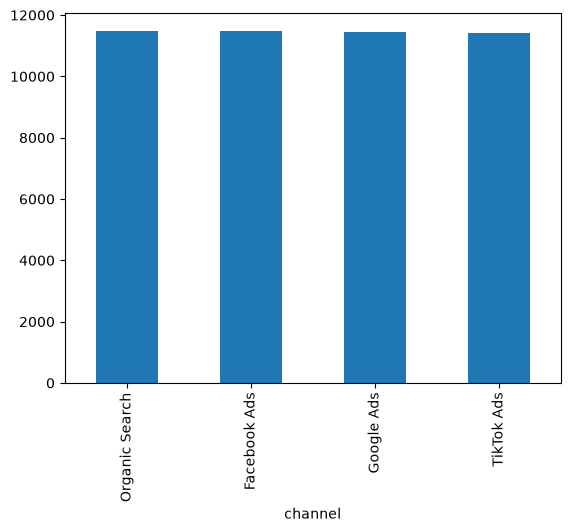

In [18]:
touchpoints["channel"].value_counts().plot(kind="bar")